## Roots of a function using the bisection method

Archimede problem: solve the following equation

$$
    x^{3} - 3 \, x^{2} + 1 = 0
$$

We're going to use the bisection method to find $x$ iteratively

First, let's guess where $x$ lies by plotting $f(x)$:

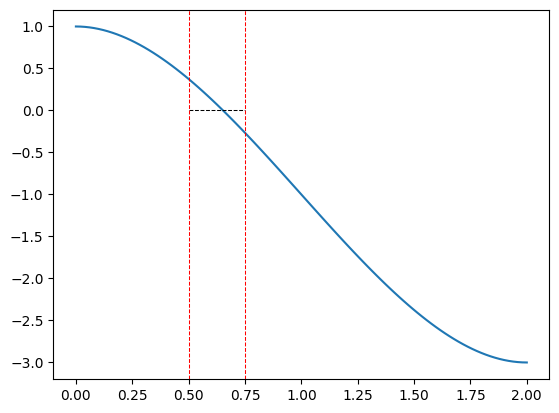

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def f(x):
    return x ** 2 * (x - 3.0) + 1

x = np.linspace(0, 2, 100)
plt.plot(x, f(x))
plt.plot([0.5, 0.75], [0, 0], linestyle = '--', color = 'black', linewidth = 0.75)
plt.axvline(0.5, linestyle = '--', color = 'red', linewidth = 0.75)
plt.axvline(0.75, linestyle = '--', color = 'red', linewidth = 0.75)
plt.show()

### Bisection method

You start with two points, $a$ and $b$, where the function has opposite signs, meaning the root lies somewhere between them. Then you repeatedly cut that interval in half: compute the midpoint $m = (a + b)/ 2$, evaluate $f(m)$, and replace either $a$ or $b$ with $m$ so that the sign change remains. Each step halves the uncertainty, so after enough iterations, you get as close to the root as you like. It’s slow but reliable, and it always works as long as you start with a valid bracket.

In [2]:
def bisection(f, a, b, eps, tol, N):

    j = 0 # While loop guard

    m_array = []
    err_array = []
    f_array = []

    while (j < N):

        m = (a + b) / 2.0 # Compute the midpoint of [a, b]
        m_array.append(m)

        fm = f(m) # Compute the value of f at the midpoint m
        f_array.append(fm)

        if abs(fm) < tol: # f(m) is near zero. End loop
            print(f"While loop ended at j = {j}: fm is below the threshold\n")
            break

        if np.sign(fm) * np.sign(f(a)) == - 1: # x lies within [a, m]
            b = m
        else: # x lies in [m, b]
            a = m

        j += 1 # Update j

        err = abs((b - a)) / 2.0 # Update the absolute error
        err_array.append(err)

        if err < eps: # absolute error is below epsilon. End loop
            print(f"While loop ended at j = {j}: absolute error of x is below the threshold\n")
            break

        if j == N:
            print(f"While loop ended at j = {N}: maximum number of iterations reached")

    return np.array(m_array), np.array(err_array), np.array(f_array) # x values, absolute errors and f(x) values

In [3]:
a, b = 0.5, 0.75 # a = 0.5, b = 0.75
N = 20 # Maximum number of iterations
eps = 1e-04 # Maximum error of x desired
tol = 1e-06 # Maximum tolerance for f(x) desired

m_array, err_array, f_array = bisection(f, a, b, eps, tol, N)
m_array, err_array, f_array

While loop ended at j = 11: absolute error of x is below the threshold



(array([0.625     , 0.6875    , 0.65625   , 0.640625  , 0.6484375 ,
        0.65234375, 0.65429688, 0.65332031, 0.65283203, 0.65258789,
        0.65270996]),
 array([6.25000000e-02, 3.12500000e-02, 1.56250000e-02, 7.81250000e-03,
        3.90625000e-03, 1.95312500e-03, 9.76562500e-04, 4.88281250e-04,
        2.44140625e-04, 1.22070312e-04, 6.10351562e-05]),
 array([ 7.22656250e-02, -9.30175781e-02, -9.36889648e-03,  3.17115784e-02,
         1.12357140e-02,  9.49323177e-04, -4.20583040e-03, -1.62726175e-03,
        -3.38720973e-04,  3.05363224e-04, -1.66633490e-05]))

In [4]:
m_array[-1], err_array[-1], f_array[-1] # Final values

(np.float64(0.6527099609375),
 np.float64(6.103515625e-05),
 np.float64(-1.6663349015288986e-05))

In [5]:
# Plotting results function
def plot(m_array, err_array, f_array):
    fig, axes = plt.subplots(3, 1, figsize = (7, 7), sharex = True)

    axes[0].plot(m_array, 'bo-', label = 'Midpoint m')
    axes[0].set_ylabel('m')
    axes[0].set_title('Midpoints convergence')
    axes[0].grid(True)
    axes[0].legend()

    axes[1].plot(f_array, 'ro-', label = 'f(m)')
    axes[1].axhline(0, color = 'k', linestyle = '--', linewidth = 0.75)
    axes[1].set_ylabel('f(m)')
    axes[1].set_title('Function values at midpoints')
    axes[1].grid(True)
    axes[1].legend()

    axes[2].plot(err_array, 'go-', label = 'Absolute error')
    axes[2].set_xlabel('Iterations')
    axes[2].set_ylabel('Error')
    axes[2].set_title('Error convergence')
    axes[2].grid(True)
    axes[2].legend()

    fig.suptitle('Method results', fontsize = 14)

    plt.tight_layout(rect = [0, 0, 1, 0.98])
    plt.show()

    return None

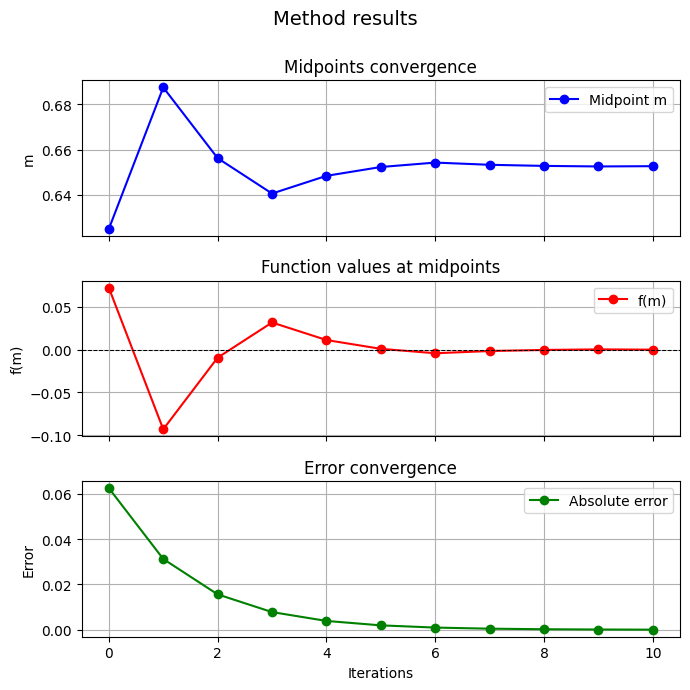

In [6]:
plot(m_array, err_array, f_array) # Plotting

We get:

$$
    x = 0.65271 \pm 0.00006
$$

Reduce $\varepsilon$ and the tolerance to get a better approximation:

In [7]:
N = 30
eps = 1e-06 # Reduced epsilon
tol = 1e-08 # Reduced tolerance

m_array, err_array, f_array = bisection(f, a, b, eps, tol, N)
m_array, err_array, f_array

While loop ended at j = 17: absolute error of x is below the threshold



(array([0.625     , 0.6875    , 0.65625   , 0.640625  , 0.6484375 ,
        0.65234375, 0.65429688, 0.65332031, 0.65283203, 0.65258789,
        0.65270996, 0.65264893, 0.65267944, 0.6526947 , 0.65270233,
        0.65270615, 0.65270424]),
 array([6.25000000e-02, 3.12500000e-02, 1.56250000e-02, 7.81250000e-03,
        3.90625000e-03, 1.95312500e-03, 9.76562500e-04, 4.88281250e-04,
        2.44140625e-04, 1.22070312e-04, 6.10351562e-05, 3.05175781e-05,
        1.52587891e-05, 7.62939453e-06, 3.81469727e-06, 1.90734863e-06,
        9.53674316e-07]),
 array([ 7.22656250e-02, -9.30175781e-02, -9.36889648e-03,  3.17115784e-02,
         1.12357140e-02,  9.49323177e-04, -4.20583040e-03, -1.62726175e-03,
        -3.38720973e-04,  3.05363224e-04, -1.66633490e-05,  1.44353820e-04,
         6.38462057e-05,  2.35916709e-05,  3.46422161e-06, -6.59954854e-06,
        -1.56765967e-06]))

In [8]:
m_array[-1], err_array[-1], f_array[-1] # Final values obtained

(np.float64(0.6527042388916016),
 np.float64(9.5367431640625e-07),
 np.float64(-1.5676596729630177e-06))

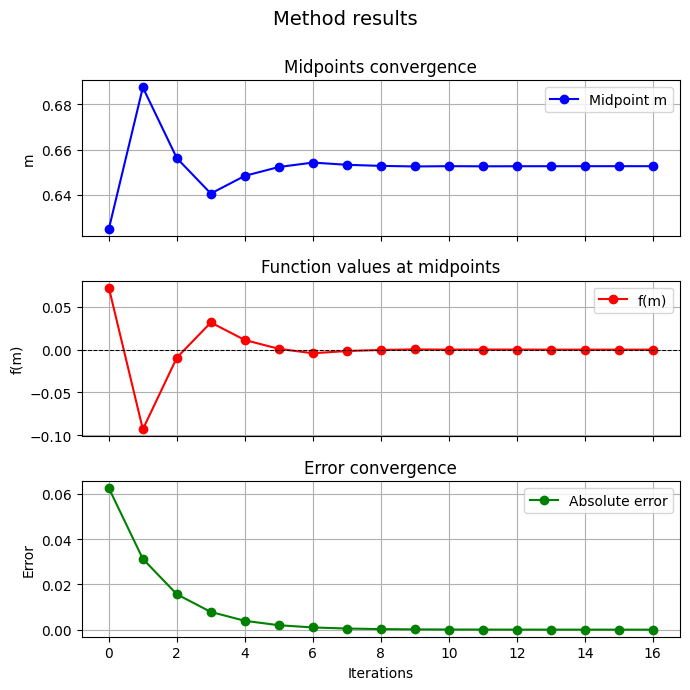

In [9]:
plot(m_array, err_array, f_array) # Plotting

With $\varepsilon = 10^{-6}$ we get:

$$
    x = 0.6527042 \pm 0.0000009
$$